✅ Walk complete! It took 212 steps to cover all 34 nodes.


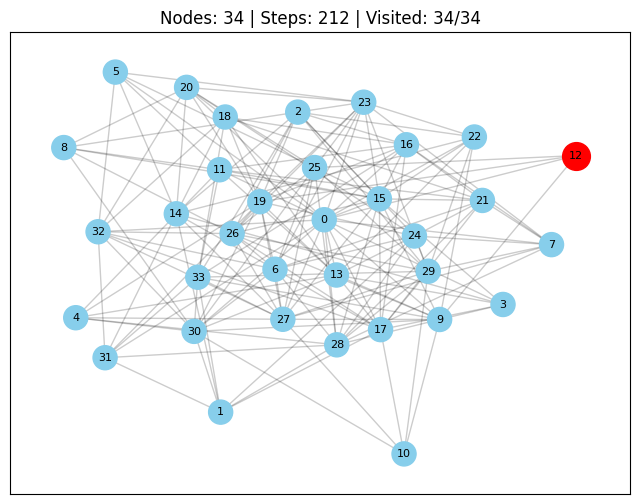

In [1]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
import time

def simulate_and_visualize(n=20, p=0.3, speed=0.1):
    """
    Simulates a random walk until all nodes are visited.
    Visualizes the process dynamically.
    """
    # 1. Create a connected graph (Ensures the walk can actually finish)
    G = nx.erdos_renyi_graph(n, p)
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(n, p)

    pos = nx.spring_layout(G)
    start_node = random.randint(0, n-1)
    visited = {start_node}
    current_node = start_node
    steps = 0

    # Setup the plot
    fig, ax = plt.subplots(figsize=(8, 6))

    while len(visited) < n:
        # Pick a neighbor randomly
        neighbors = list(G.neighbors(current_node))
        next_node = random.choice(neighbors)

        # Update state
        steps += 1
        current_node = next_node
        visited.add(current_node)

        # --- Visualization Logic ---
        if steps % 1 == 0: # Update every step
            ax.clear()
            # Draw edges
            nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
            # Draw nodes (Unvisited = Grey, Visited = Light Blue)
            node_colors = ['#87CEEB' if node in visited else '#D3D3D3' for node in G.nodes()]
            nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, ax=ax)
            # Draw Current Position (Red)
            nx.draw_networkx_nodes(G, pos, nodelist=[current_node], node_color='red', node_size=400, ax=ax)
            # Labels
            nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

            ax.set_title(f"Nodes: {n} | Steps: {steps} | Visited: {len(visited)}/{n}")
            display(fig)
            clear_output(wait=True)
            time.sleep(speed)

    print(f"✅ Walk complete! It took {steps} steps to cover all {n} nodes.")

# --- Interactive UI ---
style = {'description_width': 'initial'}
n_slider = widgets.IntSlider(value=20, min=5, max=50, step=1, description='Number of Nodes:', style=style)
p_slider = widgets.FloatSlider(value=0.3, min=0.1, max=1.0, step=0.05, description='Edge Probability (p):', style=style)
speed_slider = widgets.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.05, description='Animation Speed:', style=style)
button = widgets.Button(description="Run Simulation", button_style='success')

def on_button_clicked(b):
    simulate_and_visualize(n_slider.value, p_slider.value, speed_slider.value)

button.on_click(on_button_clicked)
display(widgets.VBox([n_slider, p_slider, speed_slider, button]))